In [1]:
import os
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns

In [2]:
from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt


def calculate_gait_mae(ground_truth: np.ndarray, prediction: np.ndarray, tolerance: int = 20):
    """
    Matches gait events and computes overall and per-class MAE in one pass.

    Args:
        ground_truth: Array of ground truth labels.
        prediction: Array of predicted labels.
        tolerance: Max distance to consider a match.

    Returns:
        A tuple containing:
        - overall_mae (float): The MAE across all matched events.
        - per_class_mae (dict): A dictionary mapping class labels to their MAE.
    """
    gt_indices = np.where(ground_truth > 0)[0]
    available_preds = list(np.where(prediction > 0)[0])
    
    # Store tuples of (label, absolute_error) for each successful match
    errors_by_class = []
    
    # Greedily match each ground truth event to the closest prediction
    for gt_idx in gt_indices:
        gt_label = ground_truth[gt_idx]
        best_dist = float('inf')
        best_match_idx = -1
        
        # Find the closest available prediction of the same class within tolerance
        for pred_idx in available_preds:
            if prediction[pred_idx] == gt_label:
                dist = abs(gt_idx - pred_idx)
                if dist <= tolerance and dist < best_dist:
                    best_dist = dist
                    best_match_idx = pred_idx
        
        # If a match is found, record its error and remove it from the pool
        if best_match_idx != -1:
            error = abs(gt_idx - best_match_idx)
            errors_by_class.append((gt_label, error))
            available_preds.remove(best_match_idx)
            
    if not errors_by_class:
        return np.nan, {}

    # --- Calculate Final Metrics ---
    
    # Overall MAE is the mean of all collected errors
    all_errors = [err for lbl, err in errors_by_class]
    overall_mae = np.mean(all_errors)
    
    # Per-class MAE is calculated by grouping errors by label
    unique_labels = sorted(np.unique([lbl for lbl, err in errors_by_class]))
    per_class_mae = {
        int(label): np.mean([err for lbl, err in errors_by_class if lbl == label])
        for label in unique_labels
    }
    
    return overall_mae, per_class_mae


# @hydra.main(config_path="../configs", config_name="train_config", version_base="1.3")
def eval(data_set: str, model_fpath: str, fold: int, return_preds_targets=None):
    with initialize(config_path="../configs", job_name="train", version_base="1.3"):
        config = compose(config_name="train_config")
    pl.seed_everything(config.general.random_state)
    all_files = glob(config.general.data_path, recursive=True)
    all_files = np.sort(all_files)
    print(f"Processing: {len(all_files)} samples")

    ids = [int(i.split("/")[-1].split("_")[0]) for i in all_files]
    group_df = pd.read_csv(config.general.group_file, index_col="ID")
    group_df.columns = ["group"]
    group_df = group_df[group_df.group.notna()]
    group_df.replace("h", 0, inplace=True)
    group_df.replace("p", 1, inplace=True)
    grouping = group_df.loc[ids].group.values

    skf = StratifiedKFold(
        n_splits=config.general.n_splits,
        shuffle=True,
        random_state=config.general.random_state,
    )

    # Outer loop for K-Fold cross-validation
    # This loop creates the primary TEST set for each fold.
    for cur_fold, (train_val_index, test_index) in enumerate(
        skf.split(np.arange(len(ids)).reshape(-1, 1), grouping)
    ):
        
        if cur_fold != fold:
            continue
        print("cur_fold", cur_fold)
        print("input fold", fold)
        print(
            f"=============== FOLD {cur_fold + 1}/{config.general.n_splits} ================"
        )
        print("current_test set:", test_index)
        # Split data into a temporary training+validation set and the final test set
        X_train_val, X_test = (
            np.arange(len(ids))[train_val_index],
            np.arange(len(ids))[test_index],
        )
        print(f"X_train_val:", X_train_val)
        print(f"train_val_index:", train_val_index)
        print(f"X_test:", X_test)
        print(f"test_index:", test_index)
        
        y_train_val, y_test = grouping[train_val_index], grouping[test_index]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val,
            y_train_val,
            test_size=0.25,
            stratify=y_train_val,
            random_state=1,
        )

        model = LitSeq2Seq(
            input_dim=config.model.input_dim,
            output_dim=config.model.output_dim,
            hidden_dim=config.model.hidden_dim,
            num_layers=config.model.num_layers,
            dropout_prob=config.model.dropout_prob,
            learning_rate=config.model.learning_rate,
            teacher_forcing_ratio=config.model.teacher_forcing_ratio,
        )

        current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        run_name = f"GRU-expandlabel{config.data.expand_labels}_{current_time}"
        
        checkpoint_callback = ModelCheckpoint(
            monitor=config.training.monitor_metric,
            mode=config.training.monitor_mode,
            save_top_k=config.training.save_top_k,
            dirpath=f"{config.general.project_name}/{run_name}/checkpoints/",
            filename="model-{epoch:02d}-{val_f1score:.2f}",
        )
            
        checkpoint_callback.best_model_path = model_fpath
        print(f"Best model: {checkpoint_callback.best_model_path}")
        device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        best_model = LitSeq2Seq.load_from_checkpoint(checkpoint_callback.best_model_path).to(device_)

        testset_f1_scores = []
        testset_pc_f1_scores = []
        testset_pc_precision = []
        testset_pc_recall = []
        testset_mae = []
        testset_pc_mae = []
        testset_cm = []
        all_preds = []
        all_targets = []
        
        if data_set == "test":
            cur_set_to_test = X_test
        else:
            cur_set_to_test = X_val

        print("X_test:", X_test)
        print("X_val:", X_val)
        
        group_assigment = []
        counter = 0
        for curr_test_idx in cur_set_to_test.tolist():
            print(f" =============== Currently Evaluating curr_test_idx: {curr_test_idx} =============== ")
            if counter == 0:
                test_datamodule = GaitDataModule(all_files,
                                                 batch_size=1024,
                                                 window_size=config.data.window_size,
                                                 step_size=config.data.window_size,
                                                 train_idx=X_train.squeeze(), 
                                                 val_idx=X_val.squeeze()[:1], # We load validation/test set via the test_idx here
                                                 test_idx=[curr_test_idx],
                                                 expand_labels=0,
                                                 acc_sheet_name="Linear Accelerometer",
                                                 num_workers=16,
                                                 zscale=True,
                                                )
                test_datamodule.setup(data_set)
                trainset_stats = test_datamodule.train_dataset.zscale_stats
            
            counter+=1
            test_datamodule = GaitDataModule(all_files,
                                             batch_size=1024,
                                             window_size=config.data.window_size,
                                             step_size=config.data.window_size,
                                             train_idx=X_train.squeeze(), 
                                             val_idx=X_val.squeeze()[:1], # We load validation/test set via the test_idx here
                                             test_idx=[curr_test_idx],
                                             expand_labels=0,
                                             acc_sheet_name="Linear Accelerometer",
                                             num_workers=16,
                                             zscale=True,
                                             zscale_stats=trainset_stats,
                                            )
            
            test_datamodule.setup(data_set)
            test_dataloader = test_datamodule.test_dataloader()
            # if data_set == "test":
            #     test_dataloader = test_datamodule.test_dataloader()
            # elif data_set == "val": 
            #     test_dataloader = test_datamodule.val_dataloader()
            # else:
            #     raise ValueError(f"Not supported -> {data_set}")
            best_model.eval()
            with torch.no_grad():
                pred=[]
                target=[]
                for sample_input, sample_target in test_dataloader:
                    sample_input = sample_input.to(device_)
                    sample_target = sample_target.to(device_)
                    print(sample_input.shape)
                    predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
                    pred.append(predicted_output)
                    target.append(sample_target)
                
                cur_pred = torch.concat(pred).reshape(-1, 3)
                cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
                cur_target = torch.concat(target).reshape(-1)
                reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
                
                print("Pred", cur_pred.shape, "Target", cur_target.shape)
                # cm = MulticlassConfusionMatrix(num_classes=3, normalize="true").to(device_)
                # cm.update(cur_pred, cur_target)
                # fig_, ax_ = cm.plot()
                # plt.show()
                
                ALIGN_TOLERANCE = 3
                merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
                merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
                aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
                
                
                cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
                cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                fig_, ax_ = cm.plot()
                plt.show()
                unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
                unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                ucm_tensor = unnormalized_cm.compute()
                testset_cm.append(ucm_tensor)
                print(ucm_tensor)
                
                num_classes = 3
                f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
                f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")

                pc_f1score = MulticlassF1Score(num_classes=num_classes, average='none')
                perclass_f1scores = pc_f1score(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_f1_scores.append(perclass_f1scores)
                print(f"perclass_f1scores:", perclass_f1scores)

                pc_precision = MulticlassPrecision(num_classes=num_classes, average='none')
                perclass_precision = pc_precision(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_precision.append(perclass_precision)
                print(f"perclass_precision:", perclass_precision)

                pc_recall = MulticlassRecall(num_classes=num_classes, average='none')
                perclass_recall = pc_recall(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_recall.append(perclass_recall)
                print(f"perclass_recall:", perclass_recall)

                f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                
                overall, per_class = calculate_gait_mae(merged_targets, merged_preds)
                overall = overall.item() if not np.isnan(overall) else np.nan
                print(f"MAE overall: {overall:.4f} ✨")
                print(f"MAE per_class: {per_class} ✨")
                testset_f1_scores.append(f1_macro_score)
                testset_mae.append(overall)
                testset_pc_mae.append(per_class)
                group_assigment.append(grouping[curr_test_idx])

                if return_preds_targets:
                    all_preds.append(aligned_preds)
                    all_targets.append(merged_targets)
                
            # break
        # break
    return {
            "testset_f1_scores": torch.tensor(testset_f1_scores).numpy(),
            "testset_pc_f1_scores": torch.stack(testset_pc_f1_scores).numpy(),
            "testset_pc_precision": torch.stack(testset_pc_precision).numpy(),
            "testset_pc_recall": torch.stack(testset_pc_recall).numpy(),
            "testset_mae": np.stack(testset_mae),
            "testset_pc_mae": testset_pc_mae,
            "testset_cm": torch.stack(testset_cm).numpy(),
            "group": np.stack(group_assigment),
            "all_preds": all_preds,
            "all_targets": all_targets,
           }


# 1. Evaluate Validation set

In [3]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [0, 1, 2, 4, 8]
# exp_labels = [2]
# data_set = "val"
data_set = "val" # using train here because we are loading all dataset anyway and using training set stats to normalize data
for i in range(num_folds):
    for j in exp_labels:
        print(i, j)
        # curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        # curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/RerunExp-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        save_name = f"ZscaledRerunExp4-Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        if data_set == "test" or data_set == "val":
            save_name = f"{data_set}set_{save_name}"
        if not os.path.exists(save_name):
            print(f"=== Running model: {save_name} ===")
            testset_results = eval(data_set=data_set, model_fpath=curr_model_path, fold=i)
            np.savez(save_name, **testset_results)

0 0
0 1
0 2
0 4
0 8
1 0
1 1
1 2
1 4
1 8
2 0
2 1
2 2
2 4
2 8
3 0
3 1
3 2
3 4
3 8
4 0
4 1
4 2
4 4
4 8


# 2. Plot 

## 2.1 Plot F1-score and MAE box plot validation set

 === Processing valset_Fold1_explabel0_model-epoch=162-val_f1score=0.52.npz === 
 === Processing valset_Fold1_explabel1_model-epoch=60-val_f1score=0.78.npz === 
 === Processing valset_Fold1_explabel2_model-epoch=88-val_f1score=0.86.npz === 
 === Processing valset_Fold1_explabel4_model-epoch=58-val_f1score=0.91.npz === 
 === Processing valset_Fold1_explabel8_model-epoch=60-val_f1score=0.94.npz === 
 === Processing valset_Fold2_explabel0_model-epoch=118-val_f1score=0.39.npz === 
 === Processing valset_Fold2_explabel1_model-epoch=62-val_f1score=0.81.npz === 
 === Processing valset_Fold2_explabel2_model-epoch=53-val_f1score=0.87.npz === 
 === Processing valset_Fold2_explabel4_model-epoch=50-val_f1score=0.91.npz === 
 === Processing valset_Fold2_explabel8_model-epoch=95-val_f1score=0.95.npz === 
 === Processing valset_Fold3_explabel0_model-epoch=96-val_f1score=0.37.npz === 
 === Processing valset_Fold3_explabel1_model-epoch=60-val_f1score=0.74.npz === 
 === Processing valset_Fold3_explabel2

/tmp/ipykernel_3625677/2927744888.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([u"\u00B1 10 [ms]", u"\u00B1 20 [ms]", u"\u00B1 40 [ms]", u"\u00B1 80 [ms]"])


<bound method Axes.set_title of <Axes: xlabel="Model's Label Expansion Setting", ylabel='F1-Score'>>

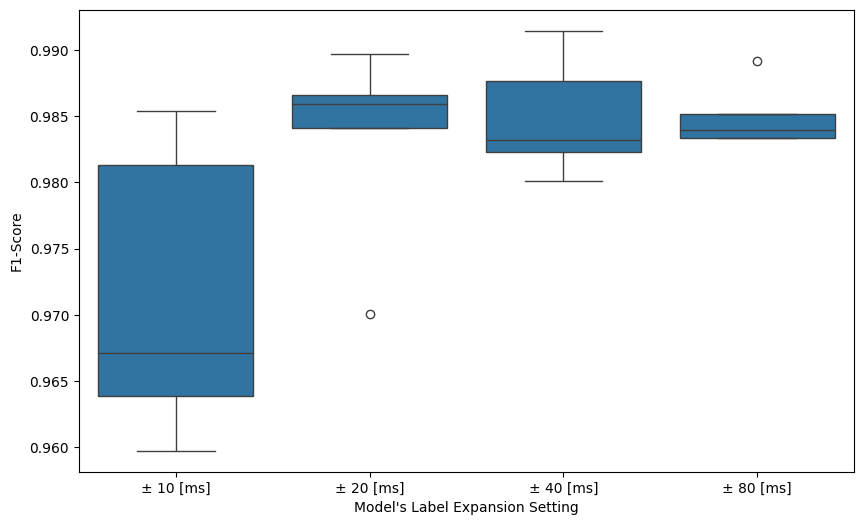

In [6]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [0, 1, 2, 4, 8]
all_results = []
for i in range(num_folds):
    for j in exp_labels:
        # curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/RerunExp-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        fname = f"valset_Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        print(f" === Processing {fname} === ")
        curr_results = np.load(fname, allow_pickle=True)
        curr_results = {**curr_results}
        curr_results["fold"] = i + 1
        curr_results["explabel"] = j
        all_results.append(curr_results)

all_results_df = pd.DataFrame(all_results)
print(all_results_df.head())

# Simplified Code for MEAN OF LIST LENGTHS
cur_feature_name = "testset_f1_scores"
cur_metric_name = "F1-Score"
f1_scores = all_results_df.groupby(["fold", "explabel"])[[cur_feature_name]].agg(lambda s: s.apply(np.nanmean))
f1_scores = f1_scores.reset_index()
f1_scores.head()

# f1_scores.groupby(["explabel"]).mean()
# f1_scores.groupby(["explabel"]).std()
plot_df = pd.melt(f1_scores[f1_scores.explabel!=0], id_vars=["fold", "explabel"])


plot_df = plot_df.rename(columns={"explabel": "Expand", "value": cur_metric_name})
plt.figure(figsize=(10, 6))
g = sns.boxplot(data=plot_df, x="Expand", y=cur_metric_name)
# plt.title("Event Detection Performance on Validation Set (5-fold CV)")
g.set_xticklabels([u"\u00B1 10 [ms]", u"\u00B1 20 [ms]", u"\u00B1 40 [ms]", u"\u00B1 80 [ms]"])
g.set_xlabel("Model's Label Expansion Setting")
g.set_title

/tmp/ipykernel_3625677/2521509924.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/tmp/ipykernel_3625677/2521509924.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(clean_labels, fontsize=14)


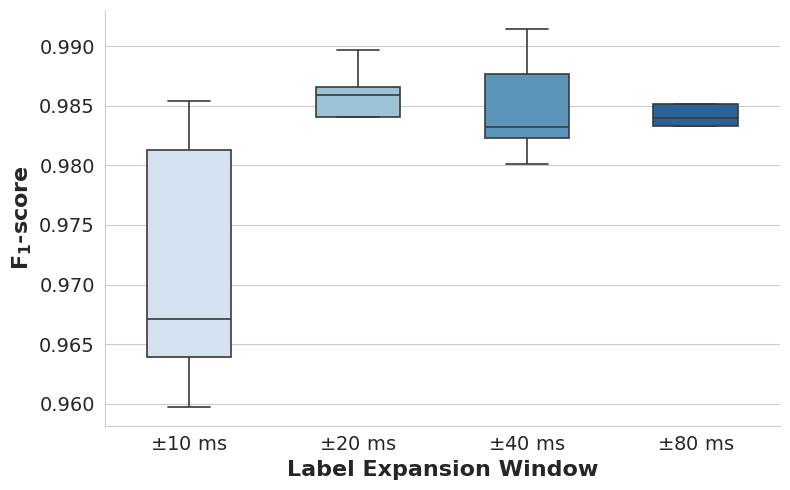

In [7]:
# JNER version
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. JNER Style Setup ---
# Use standard sans-serif fonts (Arial/Helvetica)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# --- [Your Data Loading Block Stays Here] ---
# (Assuming all_results_df is created as in your snippet)

# --- Data Preparation ---
cur_feature_name = "testset_f1_scores"
cur_metric_name = "F1-Score" 

# Process data
f1_scores = all_results_df.groupby(["fold", "explabel"])[[cur_feature_name]].agg(lambda s: s.apply(np.nanmean))
f1_scores = f1_scores.reset_index()

# Filter out 0ms if desired
plot_df = pd.melt(f1_scores[f1_scores.explabel != 0], id_vars=["fold", "explabel"])
plot_df = plot_df.rename(columns={"explabel": "Expand", "value": cur_metric_name})

# --- 2. Plotting for Publication ---

# Figure Size: 
# Journals usually have columns ~3.5 inches wide. 
# A width of 6-8 inches allows it to span two columns or be scaled down nicely.
plt.figure(figsize=(8, 5)) 

# Style: White background with grid is standard for scientific comparison
sns.set_style("whitegrid") 

# Define explicit order to ensure labels match data
# (Assuming exp_labels 1, 2, 4, 8 correspond to 10, 20, 40, 80)
order_list = [1, 2, 4, 8]

g = sns.boxplot(
    data=plot_df, 
    x="Expand", 
    y=cur_metric_name,
    order=order_list,       # Critical: Ensures X-axis is sorted correctly
    width=0.5,              # Thinner boxes look cleaner
    linewidth=1.2,          # Thicker lines for visibility in print
    palette="Blues",        # "Blues" is aesthetically pleasing and printer-safe
    showfliers=False        # Optional: Hide outliers if they distract (check journal preference)
)

# --- 3. Formatting Axes ---

# Y-Axis: Use LaTeX rendering for F1-score if possible, or consistent text
# Note: Matplotlib can render simple math-like text without full LaTeX
plt.ylabel(r"$\mathbf{F_1}$-score", fontsize=16, fontweight='bold')

# X-Axis
plt.xlabel("Label Expansion Window", fontsize=16, fontweight='bold')

# Ticks: Use the ± symbol and standard units
# Mapping 1->10ms, 2->20ms, etc. based on your previous snippet
clean_labels = [
    "$\pm$10 ms", 
    "$\pm$20 ms", 
    "$\pm$40 ms", 
    "$\pm$80 ms"
]
g.set_xticklabels(clean_labels, fontsize=14)
plt.yticks(fontsize=14)

# Remove the top and right spines (cleaner look)
sns.despine()

# --- 4. Saving ---

# Remove title (It belongs in the LaTeX caption, not the image)
# plt.title("...") 

plt.tight_layout()

# Save as PDF (Vector - Best) or PNG (Raster - High DPI)
plt.savefig("JNER2025_figures/f1_score_expansion_boxplot.pdf", bbox_inches='tight')
plt.savefig("JNER2025_figures/f1_score_expansion_boxplot.png", dpi=600, bbox_inches='tight')

plt.show()

In [8]:
# all_results_df[all_results_df.explabel==1].testset_f1_scores.apply(lambda x: x.mean()).mean()

In [9]:
import pandas as pd
import numpy as np
from scipy import stats

# --- Simplified Aggregation ---

# A single lambda function to calculate the 95% Confidence Interval bounds (CI)
# t.interval returns a tuple: (lower_bound, upper_bound)
def get_ci_bounds(series, confidence=0.95):
    """Calculates the 95% CI (lower, upper) for a Series."""
    if series.empty:
        return np.nan, np.nan
    # stats.sem calculates the Standard Error of the Mean (sigma / sqrt(n))
    sem = stats.sem(series, ddof=1)
    # stats.t.interval computes the confidence interval
    return stats.t.interval(confidence, len(series) - 1, loc=series.mean(), scale=sem)

# Assuming your DataFrame 'f1_scores' and column 'cur_feature_name' are defined.
decimals = 3

# 1. Aggregate the data (combining the CI calculation)
report_df = f1_scores.groupby('explabel')[cur_feature_name].agg(
    mean_val='mean',
    std_val='std',
    ci_bounds=get_ci_bounds, # Uses the single function to get a tuple of bounds
    count='size'
).reset_index()

# 2. Split the CI tuple into separate columns for easier formatting
report_df[['ci_lower', 'ci_upper']] = pd.DataFrame(
    report_df['ci_bounds'].tolist(),
    index=report_df.index
)
report_df = report_df.drop(columns=['ci_bounds'])


# --- Simplified Formatting (Using f-strings and round) ---

# 3. Create the formatted columns using vectorization (not row-wise apply) where possible
# Note: Using .round() before f-string formatting ensures correct precision.

# Mean +/- Std Column
report_df['Mean_Std'] = (
    report_df['mean_val'].round(decimals).astype(str) +
    ' $\\pm$ ' +
    report_df['std_val'].round(decimals).astype(str)
)

# Confidence Interval Column
report_df['95% CI'] = (
    '[' +
    report_df['ci_lower'].round(decimals).astype(str) +
    ', ' +
    report_df['ci_upper'].round(decimals).astype(str) +
    ']'
)


# 4. Select and rename final columns for publication
publication_table = report_df[['explabel', 'count', 'Mean_Std', '95% CI']]
publication_table.columns = ['Experiment Label (Group)', 'N', 'Mean $\\pm$ Std. Dev.', '95% Confidence Interval']



In [10]:
publication_table.columns = ["Label Expand", "CV-folds", 'Mean $\pm$ Std. Dev.', '95% Confidence Interval']
publication_table = publication_table.iloc[:, 1:3]
publication_table

,CV-folds,Mean $\pm$ Std. Dev.
0,5,0.481 $\pm$ 0.176
1,5,0.971 $\pm$ 0.011
2,5,0.983 $\pm$ 0.008
3,5,0.985 $\pm$ 0.005
4,5,0.985 $\pm$ 0.002


In [11]:
# Reporting validation set metrics
publication_table.to_latex()

'\\begin{tabular}{lrl}\n\\toprule\n & CV-folds & Mean $\\pm$ Std. Dev. \\\\\n\\midrule\n0 & 5 & 0.481 $\\pm$ 0.176 \\\\\n1 & 5 & 0.971 $\\pm$ 0.011 \\\\\n2 & 5 & 0.983 $\\pm$ 0.008 \\\\\n3 & 5 & 0.985 $\\pm$ 0.005 \\\\\n4 & 5 & 0.985 $\\pm$ 0.002 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [12]:
# Just get the median value
f1_scores.groupby('explabel')[cur_feature_name].agg(
    mean_val='median',
    std_val='std',
    ci_bounds=get_ci_bounds, # Uses the single function to get a tuple of bounds
    count='size'
).reset_index()

,explabel,mean_val,std_val,ci_bounds,count
0,0,0.452167,0.176385,"(0.2619913329807989, 0.7000138054164179)",5
1,1,0.967129,0.011229,"(0.9575538791266537, 0.9854400001915836)",5
2,2,0.985902,0.007652,"(0.9737507579474785, 0.9927521469444893)",5
3,4,0.983190,0.004571,"(0.9792589890200812, 0.990610028580932)",5
4,8,0.983945,0.002466,"(0.9819293440540432, 0.9880533992092014)",5


## 2.2 Test set - Plot confusion matrix with CI on the test set using best model only

In [13]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [2]
data_set = "test"

for i in range(num_folds):
    for j in exp_labels:
        # curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        save_name = f"Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        if data_set == "test":
            save_name = f"{data_set}set_{save_name}"
        if not os.path.exists(save_name):
            print(f"=== Running model: {save_name} ===")
            testset_results = eval(data_set=data_set, model_fpath=curr_model_path, fold=i)
            np.savez(save_name, **testset_results)

In [14]:
testset_all_results = []
print(f"Currently evaluating expand label: {j}")
testset_fnames = np.sort(glob(f"testset_Fold*_explabel{j}*"))
for fname in testset_fnames:
    print(f"Loading {fname}")
    curr_results = np.load(fname, allow_pickle=True)
    curr_results = {**curr_results}
    curr_results["fold"] = i + 1
    curr_results["explabel"] = j
    testset_all_results.append(curr_results)

Currently evaluating expand label: 2
Loading testset_Fold1_explabel2_model-epoch=86-val_f1score=0.88.npz
Loading testset_Fold2_explabel2_model-epoch=87-val_f1score=0.87.npz
Loading testset_Fold3_explabel2_model-epoch=61-val_f1score=0.84.npz
Loading testset_Fold4_explabel2_model-epoch=87-val_f1score=0.86.npz
Loading testset_Fold5_explabel2_model-epoch=60-val_f1score=0.84.npz


In [15]:
testset_all_results_df = pd.DataFrame(testset_all_results)
testset_all_results_df


,testset_f1_scores,testset_pc_f1_scores,testset_pc_precision,testset_pc_recall,testset_mae,testset_pc_mae,testset_cm,group,all_preds,all_targets,fold,explabel
0,"[0.9962233, 0.98238206, 0.98628074, 0.9955169,...","[[0.9998778, 0.9962547, 0.9925373], [0.9994414...","[[1.0, 0.9925373, 0.9851852], [0.99960095, 0.9...","[[0.9997557, 1.0, 1.0], [0.99928194, 0.9699248...","[0.5601503759398496, 0.8830188679245283, 1.085...","[{1: 0.5789473684210527, 2: 0.5413533834586466...","[[[12275, 1, 2], [0, 133, 0], [0, 0, 133]], [[...","[0, 0, 0, 0, 1, 0, 1, 0, 1, 1]",[],[],5,2
1,"[0.9909692, 0.89506996, 0.8945084, 1.0, 0.9942...","[[0.9997752, 0.99115044, 0.981982], [0.9966604...","[[0.99955046, 1.0, 1.0], [0.9964169, 0.71875, ...","[[1.0, 0.98245615, 0.96460176], [0.996904, 0.6...","[1.090497737556561, 1.8740458015267176, 1.7004...","[{1: 1.7946428571428572, 2: 0.3669724770642202...","[[[13341, 0, 0], [2, 112, 0], [4, 0, 109]], [[...","[0, 0, 0, 1, 1, 1, 0, 0, 0]",[],[],5,2
2,"[0.95353377, 0.9712814, 0.98975384, 0.9912957,...","[[0.99850327, 0.8659004, 0.9961977], [0.999043...","[[0.99850327, 0.86923075, 0.99242425], [0.9991...","[[0.99850327, 0.86259544, 1.0], [0.9989185, 0....","[1.318007662835249, 1.0749063670411985, 0.6550...","[{1: 2.1538461538461537, 2: 0.4885496183206106...","[[[12008, 17, 1], [18, 113, 0], [0, 0, 131]], ...","[0, 0, 0, 0, 1, 0, 1, 0, 1]",[],[],5,2
3,"[0.9899398, 0.98349655, 0.99289536, 0.9815134,...","[[0.9997157, 0.974359, 0.9957447], [0.9994406,...","[[0.99967504, 0.98275864, 0.9915254], [0.99928...","[[0.9997563, 0.9661017, 1.0], [0.9996004, 0.95...","[1.2918454935622317, 1.2756183745583038, 1.211...","[{1: 1.2241379310344827, 2: 1.358974358974359}...","[[[12306, 2, 1], [4, 114, 0], [0, 0, 117]], [[...","[0, 0, 1, 0, 0, 1, 0, 1, 1]",[],[],5,2
4,"[0.98849565, 0.98000634, 0.98076725, 0.9897920...","[[0.99967504, 0.974359, 0.991453], [0.99940234...","[[0.99959385, 0.98275864, 0.991453], [0.999442...","[[0.9997563, 0.9661017, 0.991453], [0.9993625,...","[0.7652173913043478, 1.26, 1.2920353982300885,...","[{1: 0.6491228070175439, 2: 0.8793103448275862...","[[[12306, 2, 1], [4, 114, 0], [1, 0, 116]], [[...","[0, 1, 0, 0, 0, 0, 1, 1, 1]",[],[],5,2


In [16]:
testset_all_results_df.testset_mae.apply(lambda x:len(x))

0    10
1     9
2     9
3     9
4     9
Name: testset_mae, dtype: int64

In [17]:
cm_per_fold = testset_all_results_df.testset_cm.apply(lambda x: np.stack(x).sum(0)/np.stack(x).sum(0).sum(1))
cm_per_fold

0    [[0.9996467991169978, 0.019548872180451128, 0....
1    [[0.9989715461090161, 0.08959276018099548, 0.0...
2    [[0.9993115102960506, 0.05209222886421862, 0.0...
3    [[0.9996344456629589, 0.02457627118644068, 0.0...
4    [[0.9992335662341366, 0.04125560538116592, 0.0...
Name: testset_cm, dtype: object

In [18]:
combined_cm = testset_all_results_df.testset_cm.apply(lambda x: np.stack(x).sum(0)).sum(0)
normalized_cm = (combined_cm/combined_cm.sum(1)).round(2)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# ... other imports ...

# def plot_confusion_matrix(cm, class_names, title, fmt, cbar_label, cmap=plt.cm.Blues, file_name='confusion_matrix.png'):
#     # ... (function body as executed above) ...
#     fig, ax = plt.subplots(figsize=(5, 5))
    
#     sns.heatmap(
#         cm,
#         annot=True,
#         fmt=fmt,
#         cmap=cmap,
#         linewidths=0.5,
#         linecolor='black',
#         cbar=False,
#         # cbar_kws={'label': cbar_label, 'orientation': 'vertical', 'pad': 0.04, 'aspect': 30},
#         annot_kws={"fontsize": 16, "fontweight": "bold"},
#         ax=ax,
#         square=True
#     )
    
#     ax.set_title(title, fontsize=12, fontweight='bold', pad=5)
#     ax.set_ylabel('True Label', fontsize=20, fontweight='medium')
#     ax.set_xlabel('Predicted Label', fontsize=20, fontweight='medium')

#     # Set class labels on ticks, centering them
#     tick_marks = np.arange(len(class_names))
#     ax.set_xticks(tick_marks + 0.5)
#     ax.set_yticks(tick_marks + 0.5)
#     ax.set_xticklabels(class_names, fontsize=16)
#     ax.set_yticklabels(class_names, fontsize=16, rotation=90, va="center") 

#     # Fix for half-pixel issues in matplotlib 3.1.1+ (sets the limits correctly)
#     ax.set_ylim(len(class_names), 0)
#     ax.tick_params(axis='both', which='major', length=0) 

#     plt.tight_layout()
    
#     # ... (code to set ticks and save figure) ...
#     # plt.savefig(file_name, dpi=300, bbox_inches='tight')
#     # fig.show()
#     # plt.close(fig)
#     return fig

# def plot_confusion_matrix(cm, class_names, title=None, fmt='d', cbar_label='Count', cmap=plt.cm.Blues, file_name='confusion_matrix.pdf'):
#     """
#     Plots a publication-ready confusion matrix for JNER.
#     """
    
#     # 1. Set JNER-compliant font (Arial/Helvetica is standard)
#     plt.rcParams['font.family'] = 'sans-serif'
#     plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    
#     # 2. Size: 3.5 inches is standard for single-column width (85-90mm)
#     fig, ax = plt.subplots(figsize=(5, 5)) 
    
#     sns.heatmap(
#         cm,
#         annot=True,
#         fmt=fmt,
#         cmap=cmap,
#         linewidths=1.0,        # Thicker lines for better separation in print
#         linecolor='black',
#         cbar=False,            # Disable colorbar if numbers are annotated (saves space)
#         annot_kws={"fontsize": 18, "fontweight": "bold"}, # Large font for readability when resized
#         ax=ax,
#         square=True
#     )
    
#     # 3. Titles: JNER prefers titles in the caption, not the image. 
#     # Only set if strictly necessary for internal use.
#     if title:
#         ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

#     # 4. Axis Labels: Clear and large
#     ax.set_ylabel('True Event', fontsize=18, fontweight='bold')
#     ax.set_xlabel('Predicted Event', fontsize=18, fontweight='bold')

#     # 5. Ticks: Center them and ensure readability
#     tick_marks = np.arange(len(class_names))
#     ax.set_xticks(tick_marks + 0.5)
#     ax.set_yticks(tick_marks + 0.5)
    
#     ax.set_xticklabels(class_names, fontsize=16, fontweight='medium')
#     # CHANGED: Rotation 0 is better for short labels like "IC/FO"
#     ax.set_yticklabels(class_names, fontsize=16, fontweight='medium', rotation=0, va="center") 

#     # Cleanups
#     ax.tick_params(axis='both', which='major', length=0) 
#     plt.tight_layout()
    
#     # 6. Saving: Use 600 DPI for raster or PDF/EPS for vector (Best for JNER)
#     # If saving as PNG, use 600 dpi. If PDF, dpi is less critical but good practice.
#     plt.savefig(file_name, dpi=600, bbox_inches='tight', transparent=False)
    
#     # plt.close(fig) # Uncomment to prevent display in notebooks if generating many
#     return fig

0
1
2
3
4


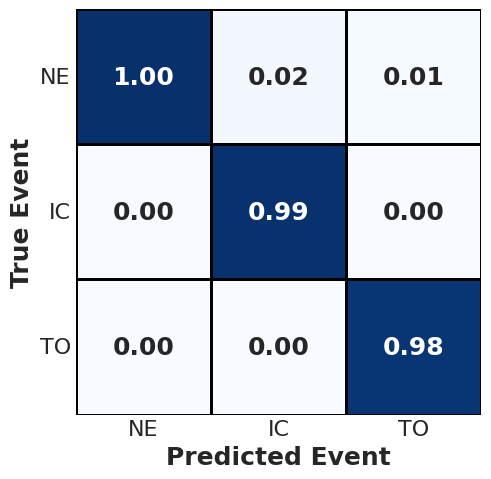

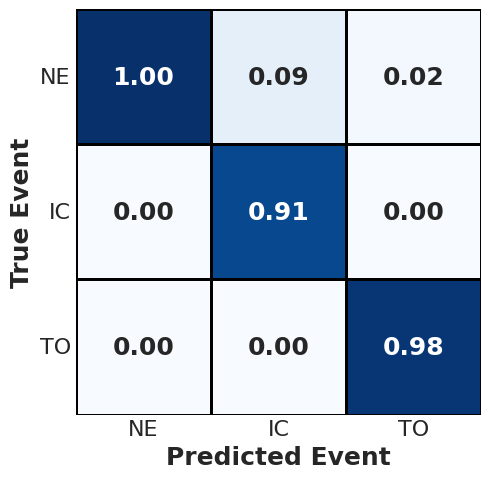

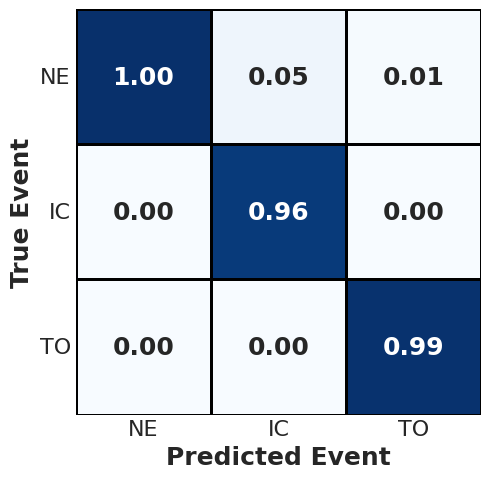

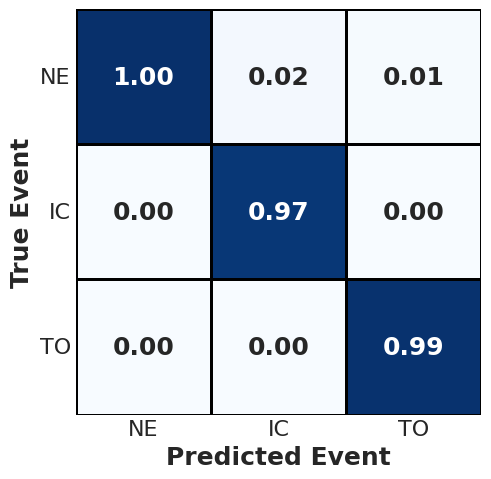

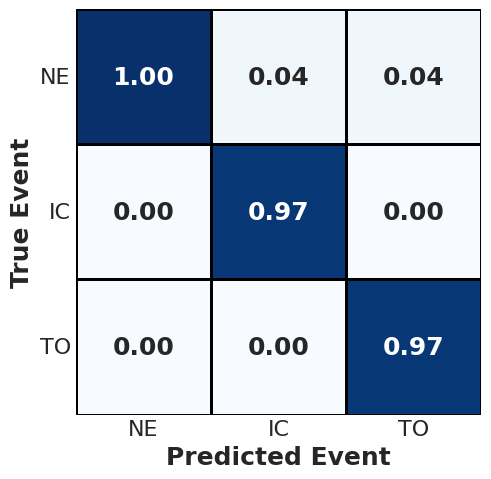

In [20]:
from gait_ml import utils
for k, v in testset_all_results_df.iterrows():
    print(k)
    # plot_confusion_matrix((np.stack(v.testset_cm).sum(0)/np.stack(v.testset_cm).sum(0).sum(1)).round(2), ["NE", "IC", "TO"], "Detection Performance on Test Set", ".2f", ["NE", "IC", "TO"])
    utils.plot_confusion_matrix(cm=(np.stack(v.testset_cm).sum(0)/np.stack(v.testset_cm).sum(0).sum(1)).round(2),
                          class_names=["NE", "IC", "TO"], 
                          title=None, 
                          fmt=".2f",
                          cbar_label="Count",
                          file_name=f"JNER2025_figures/cm-f{k+1}.pdf")

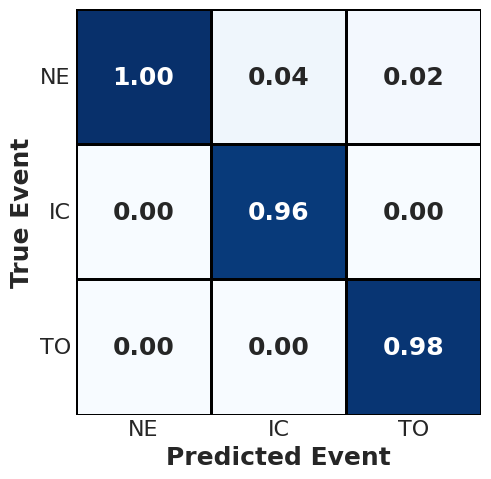

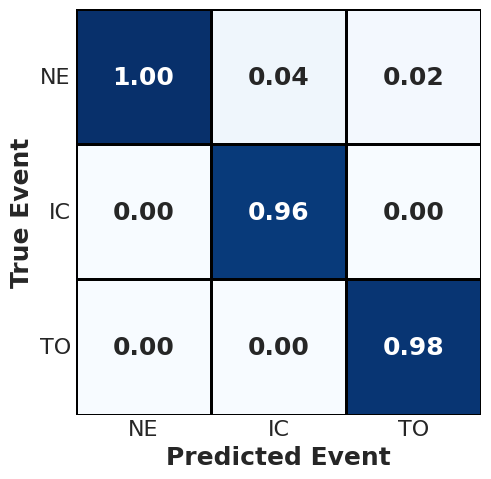

In [21]:
utils.plot_confusion_matrix(cm=normalized_cm,
                          class_names=["NE", "IC", "TO"], 
                          title=None, 
                          fmt=".2f",
                          cbar_label="Count",
                          file_name=f"JNER2025_figures/aggregated_cm_testset.pdf")

## 2.3 Table detection and MAE metrics on test set mean [std]
- F1-score, Precision, Recall, TP, FP, FN, MAE per class per group

In [22]:
metrics_per_fold = []
for k,v in testset_all_results_df.iterrows():
    print(f"==Processing fold: {k}==")
    for j in range(2):
        print(f"Group: {j}")
        curr_metrics = dict()
        curr_group = v.group
        curr_metrics["f1-score"] = v.testset_pc_f1_scores[curr_group == j].mean(0)
        curr_metrics["recall"] = v.testset_pc_recall[curr_group == j].mean(0)
        curr_metrics["precision"] = v.testset_pc_precision[curr_group == j].mean(0)
        curr_mae = pd.Series(v.testset_pc_mae[curr_group == j]).apply(lambda x: [x[idx+1] for idx in range(2)])
        curr_mae = np.stack(curr_mae).mean(0)
        curr_mae = np.hstack([np.array([np.nan]), curr_mae])
        curr_metrics["mae"] = curr_mae * 10.0
        curr_metrics["group"] = j
        curr_metrics["fold"] = k+1        
        metrics_per_fold.append(curr_metrics)

results_df = pd.DataFrame(metrics_per_fold)
# results_df.drop(columns=["fold"], inplace=True)

==Processing fold: 0==
Group: 0
Group: 1
==Processing fold: 1==
Group: 0
Group: 1
==Processing fold: 2==
Group: 0
Group: 1
==Processing fold: 3==
Group: 0
Group: 1
==Processing fold: 4==
Group: 0
Group: 1


In [23]:
# Prepare dataframe for plotting
plot_df = results_df.melt(["group", "fold"])
event_df = pd.DataFrame(plot_df['value'].apply(pd.Series))
event_df.columns = ["NE", "IC", "FO"]
plot_df.drop(columns="value", inplace=True)
plot_df = pd.concat([plot_df, event_df], axis=1)

df_long = plot_df.melt(id_vars=['group', 'fold', 'variable'], 
                  value_vars=['NE', 'IC', 'FO'],
                  var_name='event', # New column for the variable names
                  value_name='value')

df_long.group.replace(0, "Healthy", inplace=True)
df_long.group.replace(1, "BackPain", inplace=True)
df_long.variable.replace("mae", "MAE", inplace=True)
df_long.rename(columns={"variable":"Metric", "group": "Group"}, inplace=True)

/tmp/ipykernel_3625677/3551459735.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_long.group.replace(0, "Healthy", inplace=True)
/tmp/ipykernel_3625677/3551459735.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [24]:
df_long.groupby(["Metric", "Group", "event"])["value"].describe().round(3)

count    mean    std    min     25%     50%     75%  \
Metric    Group    event                                                        
MAE       BackPain FO       5.0  10.999  1.283  8.928  10.765  11.231  11.917   
                   IC       5.0  11.275  2.101  9.142   9.603  10.648  13.278   
                   NE       0.0     NaN    NaN    NaN     NaN     NaN     NaN   
          Healthy  FO       5.0   8.734  0.661  8.182   8.295   8.412   9.012   
                   IC       5.0  11.654  2.942  9.412  10.261  10.488  11.336   
                   NE       0.0     NaN    NaN    NaN     NaN     NaN     NaN   
f1-score  BackPain FO       5.0   0.983  0.014  0.960   0.979   0.988   0.993   
                   IC       5.0   0.963  0.018  0.941   0.955   0.963   0.965   
                   NE       5.0   0.999  0.000  0.999   0.999   1.000   1.000   
          Healthy  FO       5.0   0.981  0.010  0.971   0.975   0.975   0.989   
                   IC       5.0   0.956  0.042  0.885   0.953   0.977   0.981   
                   NE       5.0   0.999  0.000  0.999   0.999   1.000   1.000   
precision BackPain FO       5.0   0.982  0.016  0.957   0.977   0.991   0.992   
                   IC       5.0   0.960  0.018  0.938   0.953   0.954   0.970   
                   NE       5.0   0.999  0.000  0.999   0.999   1.000   1.000   
          Healthy  FO       5.0   0.981  0.009  0.968   0.979   0.980   0.986   
                   IC       5.0   0.953  0.040  0.886   0.946   0.977   0.978   
                   NE       5.0   0.999  0.000  0.999   1.000   1.000   1.000   
recall    BackPain FO       5.0   0.983  0.013  0.963   0.981   0.984   0.994   
                   IC       5.0   0.966  0.020  0.944   0.958   0.960   0.972   
                   NE       5.0   0.999  0.000  0.999   0.999   0.999   1.000   
          Healthy  FO       5.0   0.981  0.012  0.970   0.972   0.974   0.992   
                   IC       5.0   0.959  0.044  0.884   0.959   0.975   0.985   
                   NE       5.0   0.999  0.000  0.999   0.999   0.999   1.000   

                             max  
Metric    Group    event          
MAE       BackPain FO     12.157  
                   IC     13.704  
                   NE        NaN  
          Healthy  FO      9.769  
                   IC     16.772  
                   NE        NaN  
f1-score  BackPain FO      0.994  
                   IC      0.991  
                   NE      1.000  
          Healthy  FO      0.994  
                   IC      0.983  
                   NE      1.000  
precision BackPain FO      0.994  
                   IC      0.985  
                   NE      1.000  
          Healthy  FO      0.991  
                   IC      0.979  
                   NE      1.000  
recall    BackPain FO      0.994  
                   IC      0.996  
                   NE      1.000  
          Healthy  FO      0.996  
                   IC      0.990  
                   NE      1.000

+++++ WarningL: Excluding NE events in the plot!++++


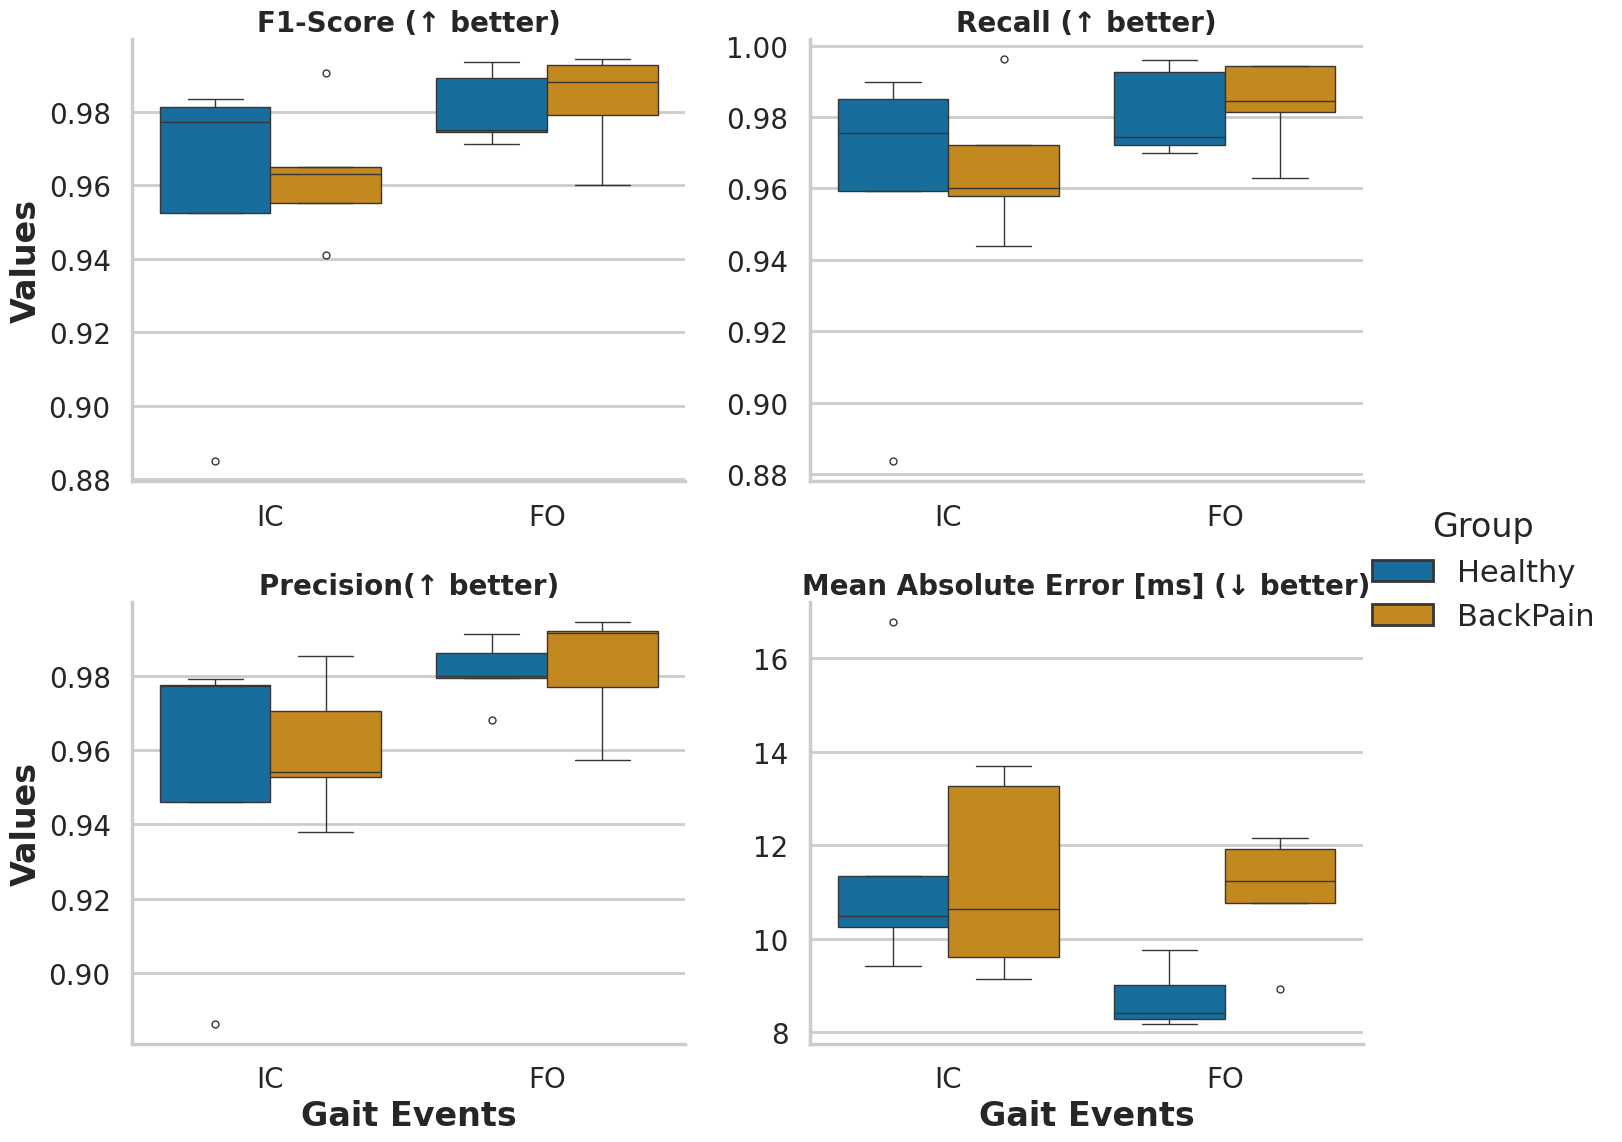

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_long is defined and contains your data
sns.set_context("poster")
print("+++++ WarningL: Excluding NE events in the plot!++++")
df_long = df_long[df_long.event != "NE"]
g = sns.catplot(data=df_long, 
                x="event", 
                y="value", 
                hue="Group", 
                kind="box", 
                col='Metric',
                col_wrap=2,
                height=6, 
                aspect=1.2, 
                sharey=False,
                sharex=False,
                palette='colorblind')

# --- Step 1: Define the custom Titles, Y-labels, and Performance Goal ---
metrics = df_long['Metric'].unique()

# # Define the custom info for each metric, now including a custom title
# custom_metrics_info = {
#     metrics[0]: {"title": "F1-Score Detection Performance", "label": "F1-Score (%)", "goal": "Higher is Better (↑)", "y_pos": 0.98}, 
#     metrics[1]: {"title": "Mean Error Results", "label": "Mean Error [ms]", "goal": "Lower is Better (↓)", "y_pos": 0.05}, 
#     metrics[2]: {"title": "Event Precision Analysis", "label": "Detection Precision", "goal": "Higher is Better (↑)", "y_pos": 0.98},
#     metrics[3]: {"title": "Root Mean Squared Error [ms]", "label": "Root Mean Squared Error", "goal": "Lower is Better (↓)", "y_pos": 0.05}
# }
custom_metrics_info = {
    metrics[0]: {"title": "F1-Score (↑ better)"}, 
    metrics[1]: {"title": "Recall (↑ better)"}, 
    metrics[2]: {"title": "Precision(↑ better)"},
    metrics[3]: {"title": "Mean Absolute Error [ms] (↓ better)"}
}

# --- Step 2: Iterate and Apply Titles, Labels, and Annotations ---
for ax_index, ax in enumerate(g.axes.flat):
    current_metric = metrics[ax_index]
    info = custom_metrics_info.get(current_metric)
    
    if info:
        # ⭐ Key Customization 1: Set the custom plot title
        ax.set_title(info["title"], fontsize=20, fontweight='bold')
        
        # Set the custom Y-axis label
        # ax.set_ylabel(info["label"], fontsize=18)
        
        # # Add text annotation to indicate the goal
        # ax.text(
        #     x=0.05, 
        #     y=info["y_pos"], 
        #     s=info["goal"], 
        #     transform=ax.transAxes, 
        #     fontsize=16,
        #     color='red' if 'Lower' in info["goal"] else 'green',
        #     fontweight='bold'
        # )

# --- Step 3: Clean up shared labels and titles ---
# Remove the default shared label from the grid
g.set_axis_labels("Gait Events", "Values", fontweight='bold') 

# Remove the default top-level title that catplot tries to set for the column
# g.set_titles(col_template='{col_name}', row_template='{row_name}', size=0) # Set size=0 to hide

# Add a main title to the figure (applies to the entire figure, not individual plots)
# g.fig.suptitle('Gait Event Detection Performance on Testset (5-fold CV)', y=1.03, fontsize=22)

# Improve tick labels (numbers/text on axes)
g.tick_params(axis='both', which='major', labelsize=20)

plt.savefig("JNER2025_figures/overall-performance2x2.pdf", bbox_inches='tight')
plt.savefig("JNER2025_figures/overall-performance2x2.png", dpi=600, bbox_inches='tight')

plt.show()

In [26]:
# plt.figure(figsize=(10, 5))

# g = sns.catplot(data=df_long, 
#                 x="event", 
#                 y="value", 
#                 hue="Group", 
#                 kind="box", 
#                 col='Metric',
#                 col_wrap=2,
#                 height=6, 
#                 aspect=1.2, 
#                 sharey=False, 
#                 palette='colorblind')
# # Add a main title to the figure
# g.fig.suptitle('Gait Event Detection Performance on Testset (5-fold CV)', y=1.03, fontsize=22)

# # Improve axis labels|
# g.tick_params(axis='both', which='major', labelsize=16)
# # plt.tight_layout(rect=[0, 0, 1, 0.97])
# g.set_axis_labels("Event", "Value")

# plt.show()

In [27]:
# # Create the plot
# g = sns.catplot(data=df_long,
#                 x="event",
#                 y="value",
#                 hue="Group",
#                 kind="box",
#                 col='Metric',
#                 # col_wrap=2,
#                 height=6,
#                 aspect=1.2,
#                 sharey=False,
#                 legend_out=True,
#                 palette='colorblind')

# # 1. Main Title
# # g.fig.suptitle('Gait Event Detection Performance on Testset (5-fold CV)', y=1.03, fontsize=20)

# # 2. Subplot Titles (e.g., "Metric = Accuracy")
# g.set_titles(size=25)

# # 3. Axis Labels
# g.set_axis_labels("Event", "Value", fontsize=25)

# # 4. Tick Labels
# g.tick_params(axis='both', which='major', labelsize=25)

# # 5. Legend Title and Labels
# if g.legend:
#     plt.setp(g.legend.get_texts(), fontsize='25')
#     plt.setp(g.legend.get_title(), fontsize='25')

# # Adjust layout
# # plt.tight_layout(rect=[0, 0, 1, 0.97])

# plt.show()

### 3. Concordance Analysis

In [28]:
from gait_ml import utils

Seed set to 42


=== Running model: testset_Fold1_explabel2_model-epoch=86-val_f1score=0.88.npz ===


/tmp/ipykernel_3625677/2210105483.py:107: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)


Processing: 46 samples
cur_fold 0
input fold 0
=============== FOLD 1/5 ================
current_test set: [ 4 11 12 13 14 20 23 24 28 34]
X_train_val: [ 0  1  2  3  5  6  7  8  9 10 15 16 17 18 19 21 22 25 26 27 29 30 31 32
 33 35 36 37 38 39 40 41 42 43 44 45]
train_val_index: [ 0  1  2  3  5  6  7  8  9 10 15 16 17 18 19 21 22 25 26 27 29 30 31 32
 33 35 36 37 38 39 40 41 42 43 44 45]
X_test: [ 4 11 12 13 14 20 23 24 28 34]
test_index: [ 4 11 12 13 14 20 23 24 28 34]
Best model: /home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-11_20-10-10/checkpoints/model-epoch=86-val_f1score=0.88.ckpt
X_test: [ 4 11 12 13 14 20 23 24 28 34]
X_val: [37 43 19 17 22 44  9 10 26]
 =============== Currently Evaluating curr_test_idx: 4 =============== 
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_41_T1/41_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilep

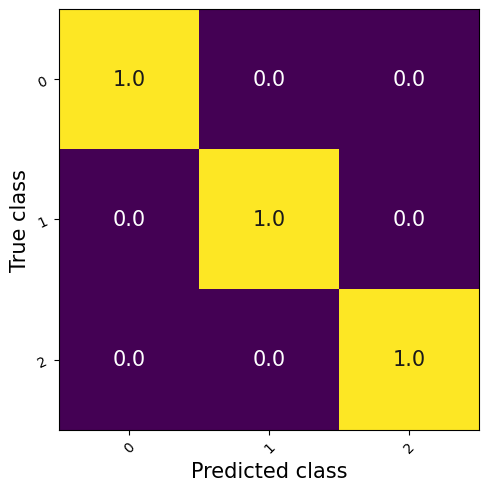

tensor([[12275,     1,     2],
        [    0,   133,     0],
        [    0,     0,   133]])
Macro F1-Score: 0.9962 ✨
perclass_f1scores: tensor([0.9999, 0.9963, 0.9925])
perclass_precision: tensor([1.0000, 0.9925, 0.9852])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 0.5602 ✨
MAE per_class: {1: np.float64(0.5789473684210527), 2: np.float64(0.5413533834586466)} ✨
 =============== Currently Evaluating curr_test_idx: 11 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_13_T1/13_1_2mW_IPh

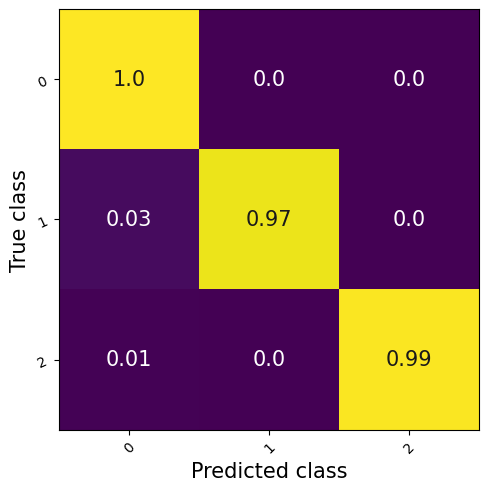

tensor([[12525,     5,     4],
        [    4,   129,     0],
        [    1,     0,   132]])
Macro F1-Score: 0.9824 ✨
perclass_f1scores: tensor([0.9994, 0.9663, 0.9814])
perclass_precision: tensor([0.9996, 0.9627, 0.9706])
perclass_recall: tensor([0.9993, 0.9699, 0.9925])
MAE overall: 0.8830 ✨
MAE per_class: {1: np.float64(1.0681818181818181), 2: np.float64(0.6992481203007519)} ✨
 =============== Currently Evaluating curr_test_idx: 12 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_14_T1/14_1_2mW_IPh

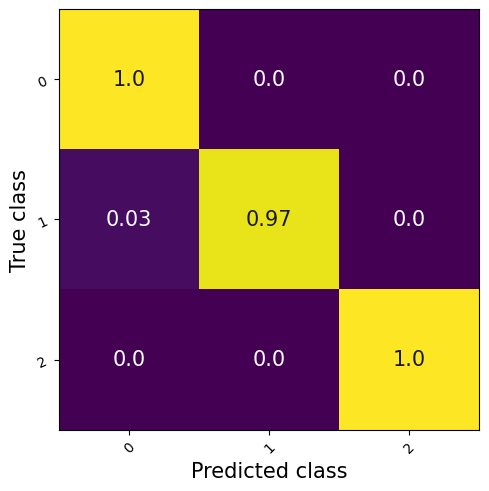

tensor([[12499,     6,     1],
        [    5,   142,     0],
        [    0,     0,   147]])
Macro F1-Score: 0.9863 ✨
perclass_f1scores: tensor([0.9995, 0.9627, 0.9966])
perclass_precision: tensor([0.9996, 0.9595, 0.9932])
perclass_recall: tensor([0.9994, 0.9660, 1.0000])
MAE overall: 1.0850 ✨
MAE per_class: {1: np.float64(1.7619047619047619), 2: np.float64(0.40816326530612246)} ✨
 =============== Currently Evaluating curr_test_idx: 13 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_15_T1/15_1_2mW_IP

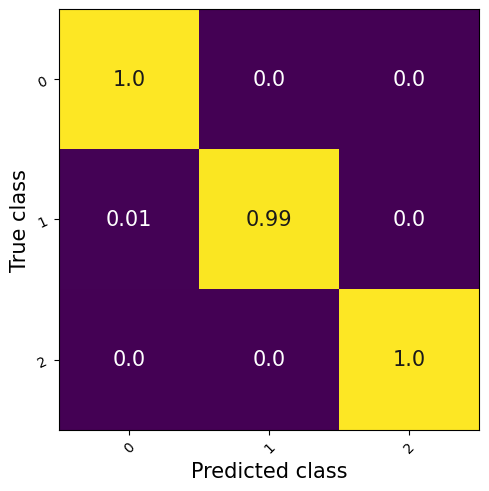

tensor([[12497,     1,     2],
        [    1,   149,     0],
        [    0,     0,   150]])
Macro F1-Score: 0.9955 ✨
perclass_f1scores: tensor([0.9998, 0.9933, 0.9934])
perclass_precision: tensor([0.9999, 0.9933, 0.9868])
perclass_recall: tensor([0.9998, 0.9933, 1.0000])
MAE overall: 0.6600 ✨
MAE per_class: {1: np.float64(0.5666666666666667), 2: np.float64(0.7533333333333333)} ✨
 =============== Currently Evaluating curr_test_idx: 14 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_16_T1/16_1_2mW_IPh

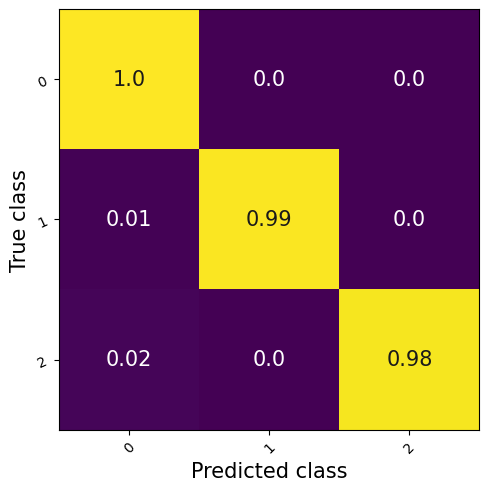

tensor([[12283,     0,     1],
        [    1,   129,     0],
        [    2,     0,   128]])
Macro F1-Score: 0.9948 ✨
perclass_f1scores: tensor([0.9998, 0.9961, 0.9884])
perclass_precision: tensor([0.9998, 1.0000, 0.9922])
perclass_recall: tensor([0.9999, 0.9923, 0.9846])
MAE overall: 1.2519 ✨
MAE per_class: {1: np.float64(0.6589147286821705), 2: np.float64(1.8449612403100775)} ✨
 =============== Currently Evaluating curr_test_idx: 20 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_23_T1/23_1_2mW_IPh

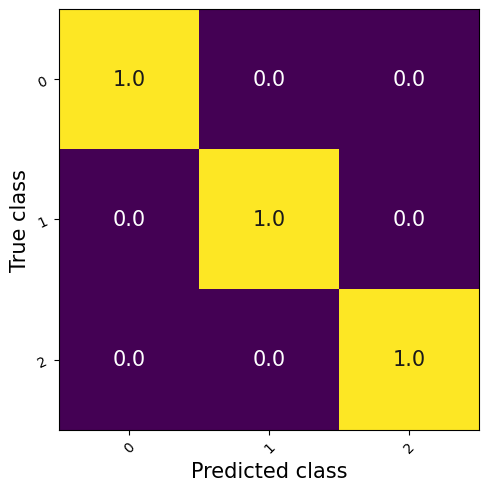

tensor([[12541,     2,     1],
        [    0,   128,     0],
        [    0,     0,   128]])
Macro F1-Score: 0.9961 ✨
perclass_f1scores: tensor([0.9999, 0.9922, 0.9961])
perclass_precision: tensor([1.0000, 0.9846, 0.9922])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 1.4062 ✨
MAE per_class: {1: np.float64(1.03125), 2: np.float64(1.78125)} ✨
 =============== Currently Evaluating curr_test_idx: 23 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_26_T1/26_1_2mW_IPhone.xls
cropped_array 

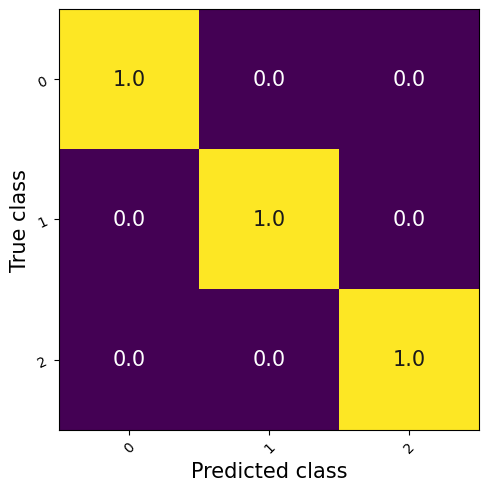

tensor([[12527,     2,     1],
        [    0,   135,     0],
        [    0,     0,   135]])
Macro F1-Score: 0.9963 ✨
perclass_f1scores: tensor([0.9999, 0.9926, 0.9963])
perclass_precision: tensor([1.0000, 0.9854, 0.9926])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 0.7963 ✨
MAE per_class: {1: np.float64(0.4222222222222222), 2: np.float64(1.1703703703703703)} ✨
 =============== Currently Evaluating curr_test_idx: 24 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_27_T1/27_1_2mW_IPh

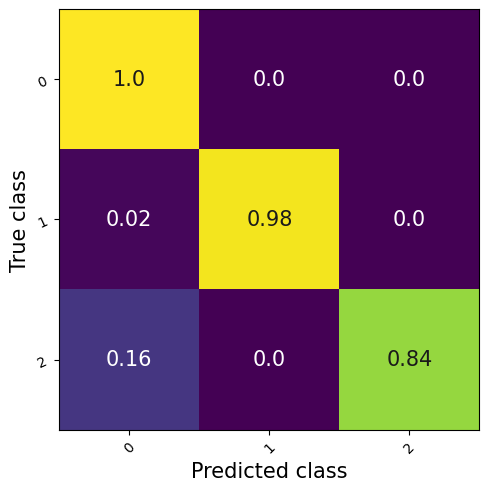

tensor([[12577,     3,     5],
        [    2,   106,     0],
        [   17,     0,    90]])
Macro F1-Score: 0.9557 ✨
perclass_f1scores: tensor([0.9989, 0.9770, 0.8911])
perclass_precision: tensor([0.9985, 0.9725, 0.9474])
perclass_recall: tensor([0.9994, 0.9815, 0.8411])
MAE overall: 0.9849 ✨
MAE per_class: {1: np.float64(1.1495327102803738), 2: np.float64(0.7934782608695652)} ✨
 =============== Currently Evaluating curr_test_idx: 28 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_31_T1/31_1_2mW_IPh

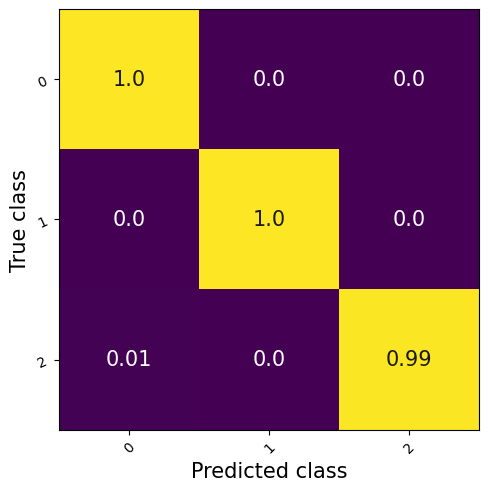

tensor([[12265,     3,     1],
        [    0,   138,     0],
        [    1,     0,   136]])
Macro F1-Score: 0.9939 ✨
perclass_f1scores: tensor([0.9998, 0.9892, 0.9927])
perclass_precision: tensor([0.9999, 0.9787, 0.9927])
perclass_recall: tensor([0.9997, 1.0000, 0.9927])
MAE overall: 1.1934 ✨
MAE per_class: {1: np.float64(1.2318840579710144), 2: np.float64(1.1544117647058822)} ✨
 =============== Currently Evaluating curr_test_idx: 34 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_37_T1/37_1_2mW_IPh

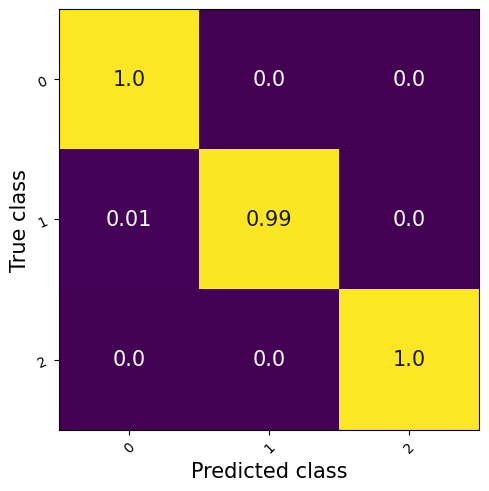

tensor([[12542,     3,     0],
        [    1,   127,     0],
        [    0,     0,   127]])
Macro F1-Score: 0.9948 ✨
perclass_f1scores: tensor([0.9998, 0.9845, 1.0000])
perclass_precision: tensor([0.9999, 0.9769, 1.0000])
perclass_recall: tensor([0.9998, 0.9922, 1.0000])
MAE overall: 1.0196 ✨
MAE per_class: {1: np.float64(1.34375), 2: np.float64(0.6929133858267716)} ✨


In [35]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [2]
data_set = "test"

for i in range(num_folds):
    if i == 0:
        for j in exp_labels:
            # curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
            curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
            save_name = f"Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
            if data_set == "test":
                save_name = f"{data_set}set_{save_name}"
            # if not os.path.exists(save_name):
            print(f"=== Running model: {save_name} ===")
            testset_results = eval(data_set=data_set, model_fpath=curr_model_path, fold=i, return_preds_targets=True)
            # np.savez(save_name, **testset_results)
    break

In [36]:
all_preds = testset_results["all_preds"]
all_targets = testset_results["all_targets"]

In [37]:
# Find all patient ids
# subject_ids = [Path(i).parents[3].name for i in test_set_fpaths]

# Take average feature per subject since there are ~
stance_pred = [utils.calculate_gait_phases_vectorized(i) for i in all_preds]
stance_target = [utils.calculate_gait_phases_vectorized(i) for i in all_targets]

stance_pred = pd.DataFrame([i.mean() for i in stance_pred])
stance_target = pd.DataFrame([i.mean() for i in stance_target])
# stance_pred = utils.aggregate_res(stance_pred, subject_ids)
# stance_target = utils.aggregate_res(stance_target, subject_ids)

In [38]:
res_df = pd.concat([stance_pred, stance_target], axis=1)
res_df

,0,0
0,61.988527,61.998176
1,59.176889,59.513763
2,60.881147,61.092694
3,59.880227,59.978442
4,59.908133,60.097155
5,57.099935,57.110981
6,56.924522,56.951606
7,63.833932,64.963275
8,58.963472,59.531568
9,60.085249,60.102315


/beegfs1/home/qivy00li/projects/gait_ml/src/gait_ml/utils.py:181: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  average,


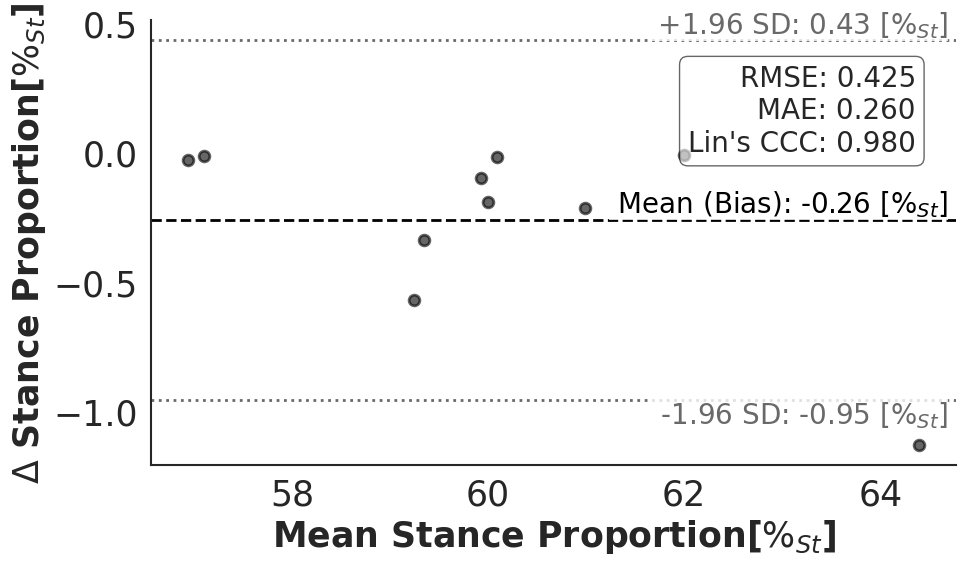

In [48]:
# 2. Call the plotting function
fig, ax = utils.plot_bland_altman_publication(
    res_df.iloc[:, 0], 
    res_df.iloc[:, 1], 
    method1_name='Pred',
    method2_name='GT',
    units=r'[$\%_{St}$]',
    filename="JNER2025_figures/bland_altman_internal.pdf"
)